In [337]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [338]:
# 4. Final Project Idea: Analyzing Data
# 4.2 Importing Data

In [339]:
# 4.2.3
df = pd.read_csv('exoplanet_data.csv', comment = "#")
df

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
3,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 d,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2019-08-23,2019-08,2019-08-29
563,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2025-09-25,2020-10,2025-09-25
564,bet Pic c,bet Pic,1,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2023-06-12,2022-09,2023-06-12
565,eps Ind A b,eps Ind A,0,3,1,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,2.237,0.240,-0.240,4.34562,0.007374,-0.007374,2019-10-18,2019-12,2019-10-24


In [340]:
# 4.2.4
df.shape
# 567 rows by 92 columns
df.columns
# I am unsure what these columns mean: 'sy_pnum', pl_controv_flag', 'st_met', and 'sy_kmag'

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [341]:
# 4.3 Reducing Data
# # 4.3.3

# Table Label: Planet Name / Database Column Name: pl_name
# Parameter: Planet name most commonly used in the literature
# Parameter Meaning: The most common name for a planet, such as Jupiter.

# Table Label: Host Name / Database Column Name: hostname
# Parameter: Stellar name most commonly used in the literature
# Parameter Meaning: The most common name for a star, such as the Sun.

# Table Label: Discovery Method / Database Column Name: discoverymethod
# Parameter: Method by which the planet was first identified
# Parameter Meaning: How a celestial object was identified, such as via telescope.

# Table Label: Spectral Type / Database Column Name: st_spectype
# Parameter: Classification of the star based on their spectral characteristics following the Morgan-Keenan system
# Parameter Meaning: Either O, B, A, F, G, K, or M representing catagories of temperature and luminosity of stars.

# Table Label: Equilibrium Temperature [K] / Database Column Name: pl_eqt
# Parameter: The equilibrium temperature of the planet as modeled by a black body heated only by its host star, 
# or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity 
# if the planet were a black body
# Parameter Meaning: Temperature of planet based on stars luminosity and distance from star.

# Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass] / Database Column Name: pl_bmassj
# Parameter: Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), 
# depending on availability, and measured in Jupiter masses
# Parameter Meaning: Most accurate estimation of planet mass in the units of Jupiter masses.

In [342]:
# 4.3.4
new_df = df[['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']]
new_df

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
0,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.912000
1,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,0.870000
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
...,...,...,...,...,...,...
562,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,9.000000
563,bet Pic c,bet Pic,Radial Velocity,NaN,1250.0,8.200000
564,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,10.139000
565,eps Ind A b,eps Ind A,Radial Velocity,K2 V,NaN,3.250000


In [343]:
# 4.3.5
new_df1 = new_df.dropna()
new_df1

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000
...,...,...,...,...,...,...
545,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980000
548,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000000
553,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300000
556,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709000


In [344]:
# 4.3.6
new_df1.shape
# 67 rows by 6 columns
new_df1.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [345]:
# 4.3.6
new_df1.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
545,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
548,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
553,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
556,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
566,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [346]:
# 4.3.6
new_df1.columns

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')

In [347]:
# 4.4 Analyze Data
# 4.4.1

new_df1.value_counts('discoverymethod')
# Transit, Radial velocity, and imaging.
# There are 52 transit discoveries, 13 radial velocity discoveries, and 2 imaging discoveries
# Transit: Observing a planet passing infront of its star which causes a dip in the star's light level.
# Radial Velocity: Observing the movement of a star due to the gravitional pull from the discovered oribiting planet(s)
# Imaging: Using telescopes or images to directly observe planets.

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

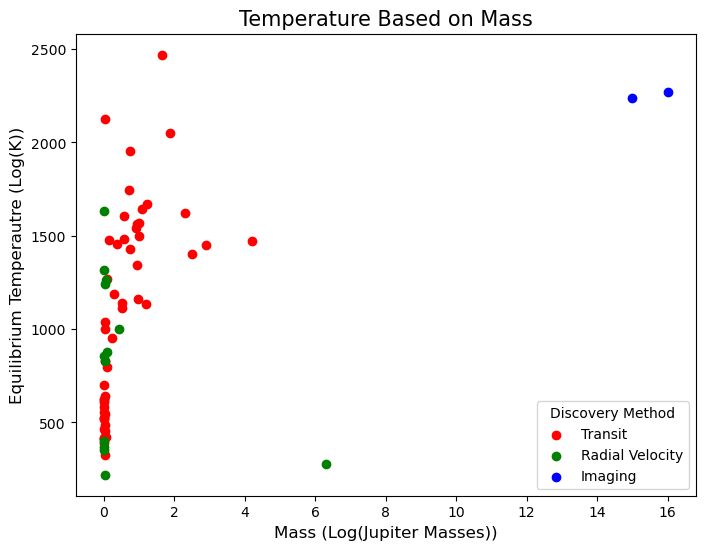

In [348]:
# 4.4.2
Transit_df = new_df1[new_df1['discoverymethod'] == 'Transit']
rv_df = new_df1[new_df1['discoverymethod'] == 'Radial Velocity']
im_df = new_df1[new_df1['discoverymethod'] == 'Imaging']

x1 = Transit_df['pl_bmassj']
y1 = Transit_df['pl_eqt']
x2 = rv_df['pl_bmassj']
y2 = rv_df['pl_eqt']
x3 = im_df['pl_bmassj']
y3 = im_df['pl_eqt']

plt.figure(figsize=(8,6))
plt.scatter(x1, y1, c = 'red', label = 'Transit')
plt.scatter(x2, y2, c = 'green', label = 'Radial Velocity')
plt.scatter(x3, y3, c = 'blue', label = 'Imaging')
plt.legend(title="Discovery Method")
plt.title('Temperature Based on Mass', fontsize=15)
plt.xlabel('Mass (Log(Jupiter Masses))', fontsize=12)
plt.ylabel('Equilibrium Temperautre (Log(K))', fontsize=12)
plt.show()

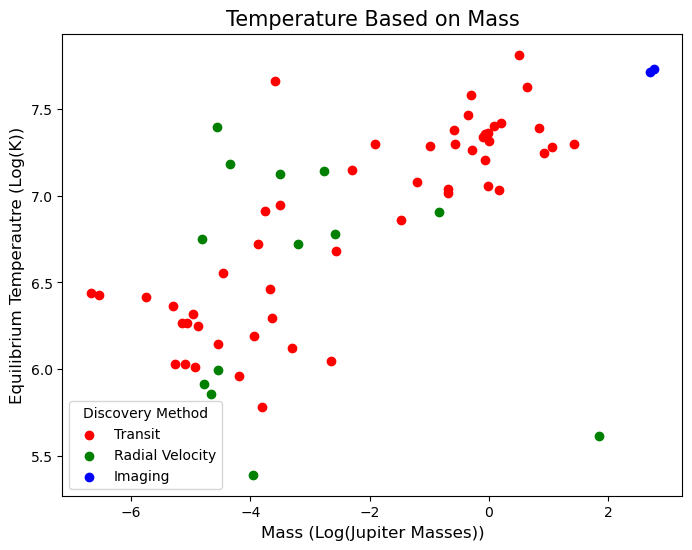

In [349]:
# 4.4.3
Transit_df = new_df1[new_df1['discoverymethod'] == 'Transit']
rv_df = new_df1[new_df1['discoverymethod'] == 'Radial Velocity']
im_df = new_df1[new_df1['discoverymethod'] == 'Imaging']

x1 = np.log(Transit_df['pl_bmassj'])
y1 = np.log(Transit_df['pl_eqt'])
x2 = np.log(rv_df['pl_bmassj'])
y2 = np.log(rv_df['pl_eqt'])
x3 = np.log(im_df['pl_bmassj'])
y3 = np.log(im_df['pl_eqt'])

plt.figure(figsize=(8,6))
plt.scatter(x1, y1, c = 'red', label = 'Transit')
plt.scatter(x2, y2, c = 'green', label = 'Radial Velocity')
plt.scatter(x3, y3, c = 'blue', label = 'Imaging')
plt.legend(title="Discovery Method")
plt.title('Temperature Based on Mass', fontsize=15)
plt.xlabel('Mass (Log(Jupiter Masses))', fontsize=12)
plt.ylabel('Equilibrium Temperautre (Log(K))', fontsize=12)
plt.show()

In [350]:
# 4.4.4
# The imiging method tends to find significantly massive planets.

In [351]:
# 4.4.5
mask = new_df1['pl_bmassj'] > 5
df_massive = new_df1[mask]
df_massive.iloc[df_massive['pl_eqt'].argmin(), 0]
# The coldest planet with a mass larger than five Jupiter Masses is 'epse Ind A b'

'eps Ind A b'

In [352]:
# 4.4.6
df_massive.iloc[2]
# eps Ind A b
# at index 2 of the masked data
# 275.0 K
# 6.31 Jupiter masses
# The star is significantly cooler and less massive than the sun

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object

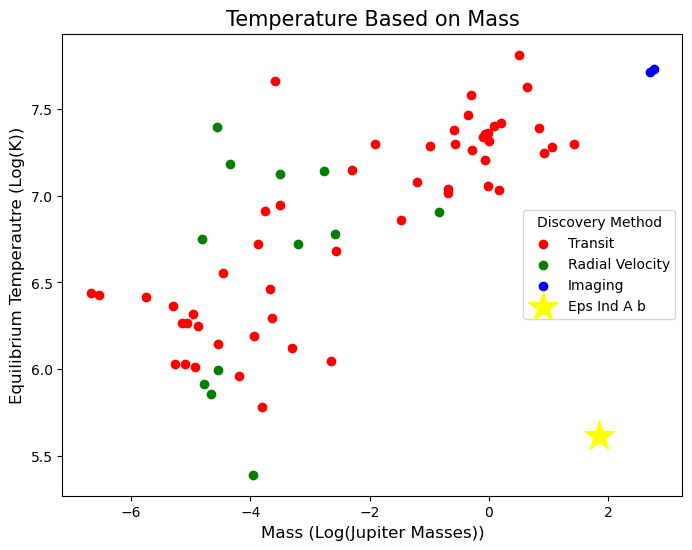

In [353]:
# 4.4.7
Transit_df = new_df1[new_df1['discoverymethod'] == 'Transit']
rv_df = new_df1[new_df1['discoverymethod'] == 'Radial Velocity']
im_df = new_df1[new_df1['discoverymethod'] == 'Imaging']

x1 = np.log(Transit_df['pl_bmassj'])
y1 = np.log(Transit_df['pl_eqt'])
x2 = np.log(rv_df['pl_bmassj'])
y2 = np.log(rv_df['pl_eqt'])
x3 = np.log(im_df['pl_bmassj'])
y3 = np.log(im_df['pl_eqt'])

new_df1.iloc[10,4] # Location of coldest star that is greater than the mass of five Jupiters
new_df1.iloc[10]   # Data of coldest star that is greater than the mass of five Jupiters 
x4 = np.log(6.31) # Mass of coldest star that is greater than the mass of five Jupiters
y4 = np.log(275.0)    # Temp of coldest star that is greater than the mass of five Jupiters

plt.figure(figsize=(8,6))
plt.scatter(x1, y1, c = 'red', label = 'Transit')
plt.scatter(x2, y2, c = 'green', label = 'Radial Velocity')
plt.scatter(x3, y3, c = 'blue', label = 'Imaging')
plt.scatter(x4, y4, c = 'yellow', label = 'Eps Ind A b', s=500, marker='*')
plt.legend(title="Discovery Method")
plt.title('Temperature Based on Mass', fontsize=15)
plt.xlabel('Mass (Log(Jupiter Masses))', fontsize=12)
plt.ylabel('Equilibrium Temperautre (Log(K))', fontsize=12)
plt.show()

In [354]:
# 4.5 Check Your Answer
# 4.5.2
# Title: A temperate super-Jupiter imaged with JWST in the mid-infrared

# Abstract: A planet was discovered by observing radial velocity that was later own imaged.
# The images changed our understanding of the planet and its properities. It is extremely bright
# heaveir than Jupiter, and has a moderate temperature.

# The star I found has the same temperature and type of host star as the planet described in the abstract,
# it is the same planet!

# It is likely the only giant planet in the system

# The temperature is both measured at 275 K and the mass is both measured at 6.31 Jupiters